In [ ]:
# Install necessary libraries
!pip install -q transformers datasets accelerate scikit-learn matplotlib huggingface_hub peft bitsandbytes

from google.colab import userdata
from huggingface_hub import login

# Authenticate Hugging Face using Colab Secrets
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
except userdata.SecretNotFoundError:
    print("WARNING: HF_TOKEN not found in Colab Secrets. Please follow the instructions to set it up.")

Successfully logged in to Hugging Face!


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"

def load_phi3_model(model_id):
    print(f"Loading {model_id} tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    print("Setting up 4-bit Quantization (QLoRA)...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

    print("Loading base model...")
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto"
    )

    model = prepare_model_for_kbit_training(model)

    print("Applying LoRA adapter...")
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules="all-linear",
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM"
    )

    peft_model = get_peft_model(model, lora_config)
    peft_model.print_trainable_parameters()

    return peft_model, tokenizer

model, tokenizer = load_phi3_model(MODEL_ID)

Loading microsoft/Phi-3-mini-4k-instruct tokenizer...
Setting up 4-bit Quantization (QLoRA)...
Loading base model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Applying LoRA adapter...
trainable params: 25,165,824 || all params: 3,846,245,376 || trainable%: 0.6543


In [ ]:
from datasets import load_dataset

def prepare_fast_chemistry_dataset(tokenizer, sample_size=1000):
    print("Downloading ScienceQA...")
    raw_science = load_dataset("derek-thomas/ScienceQA", split="train")

    print("Filtering for strictly Chemistry questions...")
    # ScienceQA has thousands of chemistry questions built-in
    science_chem = raw_science.filter(lambda x: x["topic"] == "chemistry")

    def format_science_qa(example):
        # The correct answer is an index pointing to the choices array
        correct_answer = example["choices"][example["answer"]]
        return {"text": f"Question: {example['question']}\nAnswer: {correct_answer}{tokenizer.eos_token}"}

    print("Formatting dataset to Question/Answer pairs...")
    formatted_dataset = science_chem.map(format_science_qa, remove_columns=science_chem.column_names)

    # Shuffle the data and take our 1000 examples
    final_subset = formatted_dataset.shuffle(seed=42).select(range(min(sample_size, len(formatted_dataset))))

    def tokenize_function(examples):
        # 256 is the perfect max_length for these types of questions
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

    print(f"Tokenizing {len(final_subset)} total examples...")
    return final_subset.map(tokenize_function, batched=True)

# Generating training pairs
tokenized_datasets = prepare_fast_chemistry_dataset(tokenizer, sample_size=1000)

Filtering for strictly Chemistry questions...


Filter:   0%|          | 0/12726 [00:00<?, ? examples/s]

Formatting dataset to Question/Answer pairs...


Map:   0%|          | 0/735 [00:00<?, ? examples/s]

Tokenizing 735 total examples...


Map:   0%|          | 0/735 [00:00<?, ? examples/s]

In [ ]:
import torch

# Detect the best available hardware
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"SUCCESS: NVIDIA GPU detected - {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("SUCCESS: Apple Silicon (M-series) GPU detected.")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. PyTorch will use the CPU. Training will be very slow.")

SUCCESS: NVIDIA GPU detected - Tesla T4


In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

def run_fine_tuning(model, tokenizer, dataset):
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    training_args = TrainingArguments(
        output_dir="./chem-llm-results",
        num_train_epochs=3,
        per_device_train_batch_size=4,
        learning_rate=2e-4,
        weight_decay=0.01,
        logging_steps=10,
        report_to="none",
        fp16=True,
        dataloader_pin_memory=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        data_collator=data_collator,
    )

    print("Starting Fine-Tuning...")
    trainer.train()
    print("Fine-Tuning Complete!")
    return trainer

# Execute the training
trainer = run_fine_tuning(model, tokenizer, tokenized_datasets)

Starting Fine-Tuning...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,1.991481
20,0.895840
30,0.566477
40,0.641503
50,0.495335
60,0.480204
70,0.489422
80,0.509172
90,0.481409
100,0.420730


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Fine-Tuning Complete!


In [16]:
def evaluate_model_multiple(model, tokenizer, questions):
    print("\n--- Evaluation Outputs ---\n")

    # Put the model in evaluation mode to turn off dropout layers
    model.eval()

    for i, question in enumerate(questions, 1):
        prompt = f"Question: {question}\nAnswer:"

        # Pass both input_ids and the attention_mask properly
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=60,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,
            do_sample=True
        )

        # Slice the output so it only prints the new answer, not the prompt
        input_length = inputs.input_ids.shape[1]
        generated_tokens = outputs[0][input_length:]
        answer = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        print(f"Test {i}:")
        print(f"Question: {question}")
        print(f"Answer: {answer.strip()}")
        print("-" * 50)

# A list of specific organic chemistry questions
test_questions = [
    "What is a hydrocarbon?",
    "What is the general formula for an alkane?",
    "What is a functional group in organic chemistry?",
    "What is the main difference between an alkane and an alkene?",
    "What is the structure of benzene?"
]

evaluate_model_multiple(model, tokenizer, test_questions)


--- Evaluation Outputs ---

Test 1:
Question: What is a hydrocarbon?
Answer: A compound made up of only carbon and hydrogen atoms.
--------------------------------------------------
Test 2:
Question: What is the general formula for an alkane?
Answer: CnH2n+2. This represents a hydrocarbon with single bonds only (saturated). Alkanes are saturated molecules because they contain as many hydrogen atoms as possible relative to carbon atoms.
--------------------------------------------------
Test 3:
Question: What is a functional group in organic chemistry?
Answer: A functional group is an atom or combination of atoms that gives a molecule its characteristic chemical properties. It determines how the compound behaves during reactions and can be used to identify it through various tests, such as infrared spectroscopy (IR) which detects specific
--------------------------------------------------
Test 4:
Question: What is the main difference between an alkane and an alkene?
Answer: An alkanes 

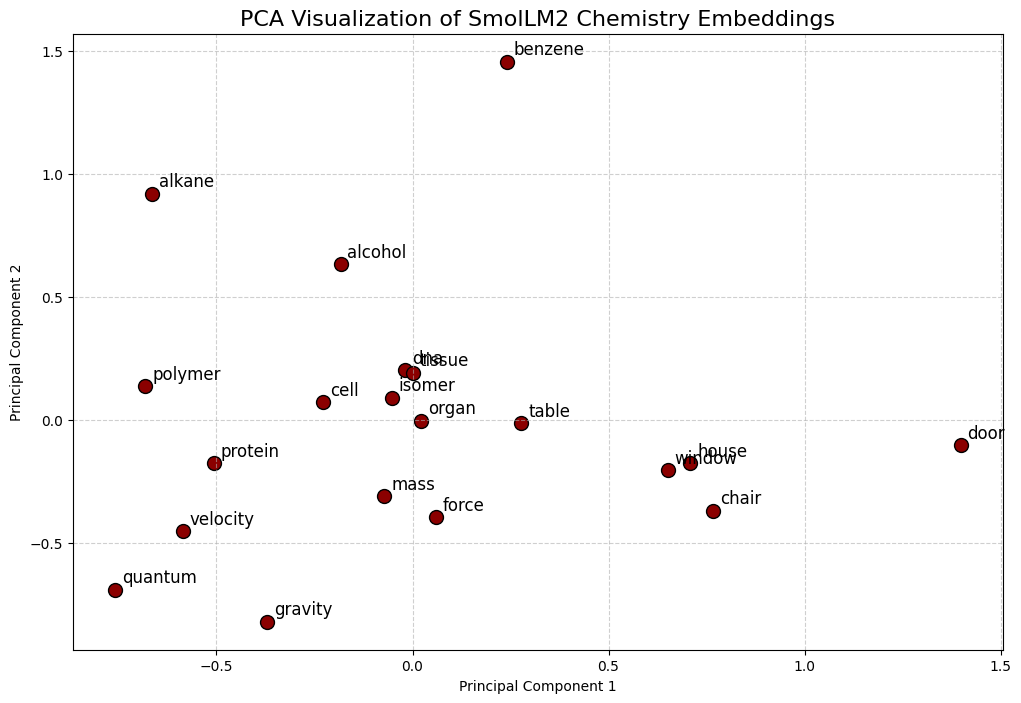

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_embeddings_pca(model, tokenizer):
    words = [
        # Organic Chemistry
        "benzene", "alkane", "alcohol", "polymer", "isomer",
        # Biology
        "cell", "protein", "dna", "tissue", "organ",
        # Physics
        "gravity", "force", "velocity", "quantum", "mass",
        # Everyday Objects
        "chair", "table", "window", "door", "house"
    ]

    word_vectors = []
    valid_words = []

    for word in words:
        inputs = tokenizer(word, return_tensors="pt", add_special_tokens=False)
        token_id = inputs['input_ids'][0][0]

        with torch.no_grad():
            # Extract internal embedding vectors
            vector = model.get_input_embeddings().weight[token_id].float().cpu().numpy()
            word_vectors.append(vector)
            valid_words.append(word)

    # Perform PCA reduction
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(np.array(word_vectors))

    # Plotting
    plt.figure(figsize=(12, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='darkred', edgecolors='k', s=100)

    for i, word in enumerate(valid_words):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                     xytext=(5, 5), textcoords='offset points', fontsize=12)

    plt.title("PCA Visualization of SmolLM2 Chemistry Embeddings", fontsize=16)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Generate the graph
visualize_embeddings_pca(model, tokenizer)